In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [75]:
df=pd.read_csv('drug200(DT).csv')


In [76]:
df.isnull().sum()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


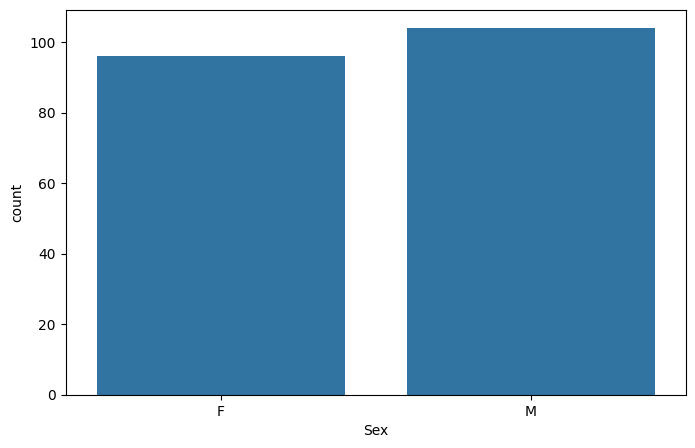

In [77]:
plt.figure(figsize=(8,5))
sns.countplot(x='Sex',data=df)
plt.show()




/tmp/ipykernel_11987/1259677068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='BP',data=df,palette='Set2')


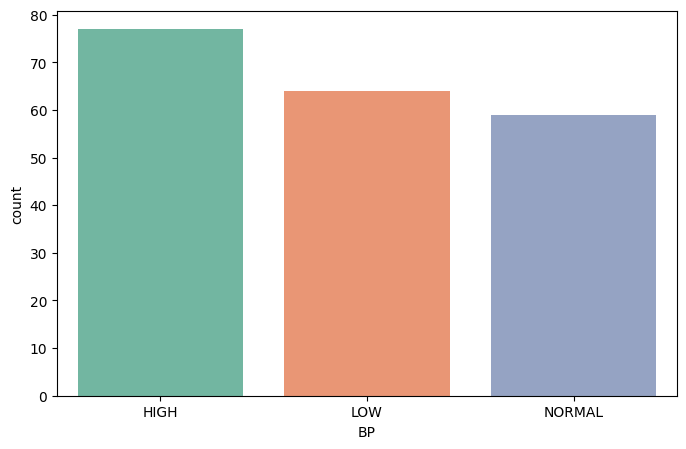

In [78]:
plt.figure(figsize=(8,5))
sns.countplot(x='BP',data=df,palette='Set2')
plt.show()

/tmp/ipykernel_11987/2911934233.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cholesterol',data=df,palette='Set1')


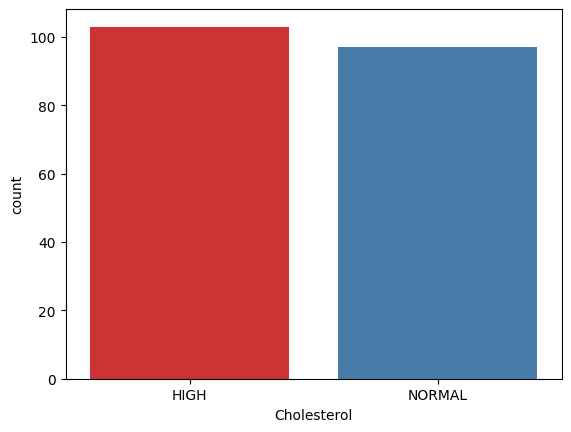

In [79]:
plt.figure.figsize=(8,5)
sns.countplot(x='Cholesterol',data=df,palette='Set1')
plt.show()

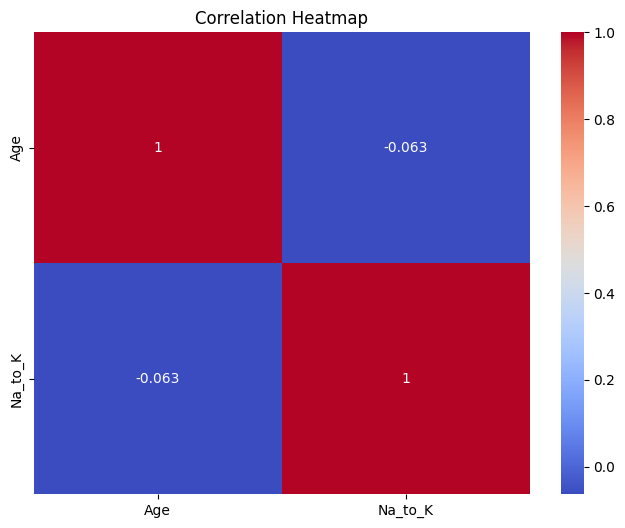

In [80]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [81]:
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])
df['BP'] = LabelEncoder().fit_transform(df['BP'])
df['Cholesterol'] = LabelEncoder().fit_transform(df['Cholesterol'])
df['Drug'] = LabelEncoder().fit_transform(df['Drug'])

In [82]:
X=df.drop('Drug',axis=1)
y=df['Drug']

In [83]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [84]:
model = DecisionTreeClassifier(criterion='entropy',splitter='best',max_features=5, max_depth=3, random_state=42)

In [85]:
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, max_features=5,
                       random_state=42)

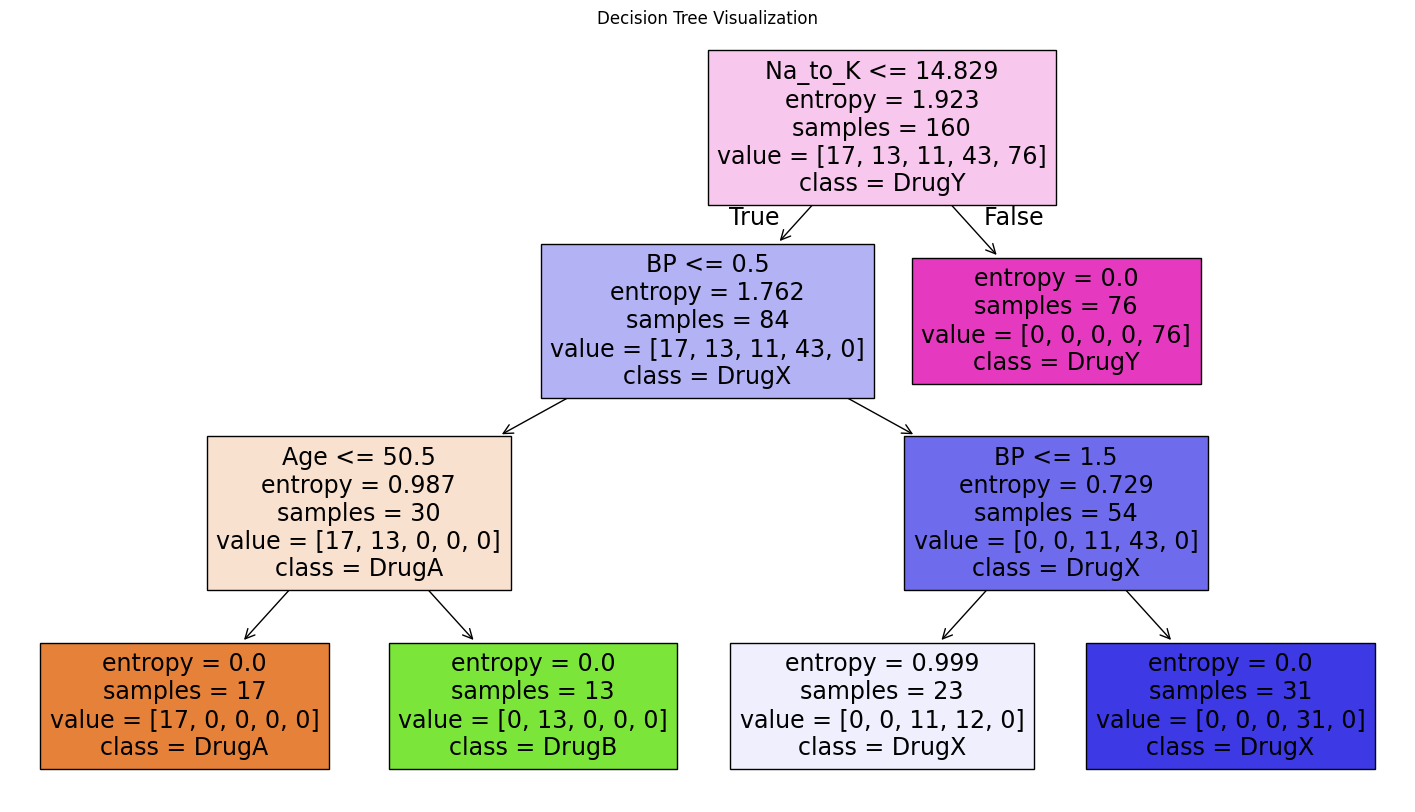

In [86]:
plt.figure(figsize=(18,10))
plot_tree(model, feature_names=X.columns, class_names=['DrugA','DrugB','DrugC','DrugX','DrugY'], filled=True)
plt.title('Decision Tree Visualization')
plt.show()

In [87]:
y_pred = model.predict(x_test)
display(y_pred)

array([3, 4, 3, 3, 4, 4, 4, 3, 0, 3, 0, 3, 4, 0, 1, 4, 1, 3, 3, 4, 1, 3,
       3, 4, 4, 4, 3, 3, 4, 3, 4, 3, 3, 4, 0, 4, 3, 0, 4, 0])

In [88]:
import pickle

model_filename = 'decision_tree_model.pkl'

with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model successfully saved as '{model_filename}'")

Model successfully saved as 'decision_tree_model.pkl'


In [89]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of the Decision Tree model: {accuracy:.2f}')

Accuracy of the Decision Tree model: 0.88


In [90]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(results.head())

,Actual,Predicted
95,3,3
15,4,4
30,3,3
158,2,3
128,4,4
